In [12]:
import sys
sys.executable

# PyTorch Classifier - Wine Quality Detection

In [1]:
import numpy as np
import torch
import kagglehub
from pathlib import Path
import os
import pandas as pd
from torch.utils.data import Dataset, DataLoader

In [2]:
class WineDataset(Dataset):
    def __init__(self, dataset_file):
        self.dataset_file = pd.read_csv(dataset_file)

    def __len__(self):
        return len(self.dataset_file)

    def __getitem__(self, idx):
        X = torch.tensor(self.dataset_file.iloc[idx, :-1].values, dtype=torch.float32)
        y = torch.tensor(self.dataset_file.iloc[idx, -1], dtype=torch.float32)

        return X, y

In [3]:
wine_dataset = WineDataset("data/winequality-red.csv")

## Try some dimensionality reduction (PCA)

In [15]:
X, y = wine_dataset[:]
X = np.array(X)
y = np.array(y)

In [21]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

PCA_model = PCA(n_components=2)
X_reduced = PCA_model.fit_transform(X_scaled)

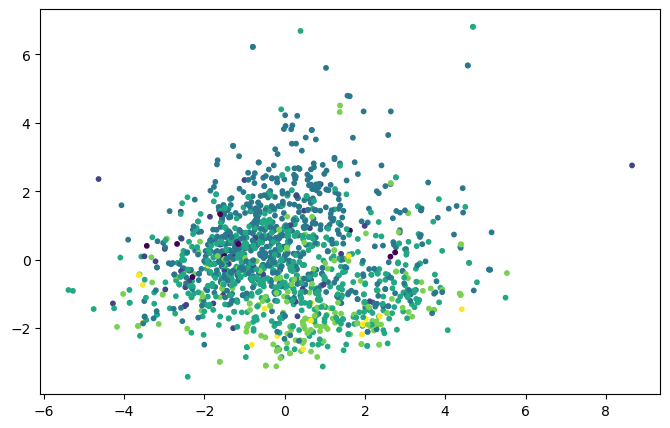

In [26]:
import matplotlib.pyplot as plt
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, s=10)

No evident clusters are highlighted

## Neural Network Approach (PyTorch)

In [65]:
df = wine_dataset.dataset_file

In [83]:
from sklearn.model_selection import train_test_split

scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [87]:
X_train

array([[ 7.3  ,  1.07 ,  0.09 , ...,  3.3  ,  0.57 ,  9.   ],
       [ 6.8  ,  0.47 ,  0.08 , ...,  3.3  ,  0.65 ,  9.6  ],
       [ 9.5  ,  0.735,  0.1  , ...,  3.23 ,  0.56 , 10.1  ],
       ...,
       [ 9.9  ,  0.35 ,  0.38 , ...,  3.26 ,  0.82 , 10.6  ],
       [11.5  ,  0.31 ,  0.51 , ...,  3.03 ,  0.93 ,  9.8  ],
       [ 9.4  ,  0.395,  0.46 , ...,  3.27 ,  0.64 , 12.2  ]],
      dtype=float32)